# Phase 2 — Network Audit: Graph-Theoretic Bottleneck Discovery
### Logistics ETA Estimation Pipeline

---

**Objective:**  
Perform a rigorous mathematical audit of the physical logistics network — represented as a
Directed Weighted Graph — to expose structural chokepoints, chronically delayed corridors, and
facilities that are the root cause of systemic SLA breaches.

**Why this matters:**  
OSRM generates predictions assuming frictionless, real-world-optimal routing. This audit
*proves* where and why that assumption collapses by mapping actual delivery delay ratios onto
every edge and hub in the network. The output feeds directly into the GraphSAGE feature
engineering pipeline in Phase 3.

**Inputs:** `data_part_1.csv`, `data_part_2.csv`, `data_part_3.csv`  
**Key Columns Used:**
- `source_center` / `source_name` → origin facility identifier
- `destination_center` / `destination_name` → destination facility identifier
- `segment_actual_time` → actual time taken for that segment (minutes)
- `segment_osrm_time` → OSRM-predicted time for that segment (minutes)
- `segment_osrm_distance` → OSRM-predicted distance (km) for that segment
- `segment_factor` → pre-computed ratio (actual / osrm) at the segment level

**Pipeline Stages:**

| # | Stage | Output |
|---|-------|--------|
| 1 | Data Ingestion & Graph Construction | Cleaned DataFrame + DiGraph `G` |
| 2 | Mathematical Audit — Centrality Metrics | Node metrics DataFrame |
| 3 | Bottleneck Discovery (>20 % threshold) | Flagged edge DataFrame |
| 4 | Visualization & SLA Breach Ranking | Plot + Top-10 offender table |

---
## Section 1 — Environment Setup & Imports

All third-party dependencies are imported here so that a missing package surfaces
immediately rather than deep inside a long computation.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────
import warnings
import logging
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# ── Numerical / tabular ───────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Graph analytics ───────────────────────────────────────────────────────
import networkx as nx

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger("network_audit")

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_theme(style="whitegrid", palette="muted")

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"networkx {nx.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"seaborn {sns.__version__}")

pandas  3.0.3
numpy   2.4.6
networkx 3.6.1
matplotlib 3.11.0
seaborn 0.13.2


---
## Section 2 — Data Ingestion & Graph Construction Layer

### 2.1 — Business Context

Each CSV row represents **one segment** of a multi-leg shipment journey.  
The columns we care about most are:

| Column | Role in Graph |
|--------|--------------|
| `source_center` | Origin node ID |
| `destination_center` | Destination node ID |
| `source_name` | Human-readable origin label |
| `destination_name` | Human-readable destination label |
| `segment_actual_time` | Numerator of delay ratio |
| `segment_osrm_time` | Denominator of delay ratio |
| `segment_factor` | Pre-computed ratio (validated against our own calculation) |
| `segment_osrm_distance` | Edge attribute (distance in km) |

### 2.2 — Data Quality Strategy

| Problem | Treatment |
|---------|-----------|
| Null in source/destination | Drop — unroutable segment |
| `segment_osrm_time` ≤ 0 | Drop — division by zero / bad sensor |
| `segment_actual_time` ≤ 0 | Drop — physically impossible |
| Extreme outliers (factor > 10) | Winsorise cap at 99th percentile per corridor |
| Duplicate trip-segment rows | De-duplicate on (`trip_uuid`, `source_center`, `destination_center`) |

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS — column name mapping (single source of truth)
# ─────────────────────────────────────────────────────────────────────────────

# Node identity columns
COL_SRC_ID   = "source_center"
COL_DST_ID   = "destination_center"
COL_SRC_NAME = "source_name"
COL_DST_NAME = "destination_name"

# Timing columns used to compute the delay factor
COL_ACTUAL   = "segment_actual_time"
COL_OSRM     = "segment_osrm_time"
COL_DISTANCE = "segment_osrm_distance"
COL_FACTOR   = "segment_factor"       # pre-computed ratio in the raw data

# Trip identifier (used for de-duplication)
COL_TRIP_ID  = "trip_uuid"

# Derived column name for our own computed ratio
COL_DELAY_RATIO = "computed_delay_ratio"

# SLA threshold: corridors where actual > 120 % of OSRM are flagged
SLA_THRESHOLD = 1.20

# File paths — adjust if running from a different working directory
from pathlib import Path

DATA_FILES = [
    Path("../data/data_part_1.csv"),
    Path("../data/data_part_2.csv"),
    Path("../data/data_part_3.csv")
]

In [3]:
def load_and_clean_data(file_paths: List[Path]) -> pd.DataFrame:
    """
    Load one or more CSV files and return a single, cleaned DataFrame
    ready for graph construction.

    Parameters
    ----------
    file_paths : list of Path
        Paths to the raw CSV segment data files.

    Returns
    -------
    pd.DataFrame
        Cleaned, de-duplicated segment-level DataFrame with an additional
        ``computed_delay_ratio`` column.

    Cleaning Steps
    --------------
    1.  Concatenate all files.
    2.  Drop rows with nulls in routing-critical columns.
    3.  Cast timing columns to float; coerce errors → NaN → drop.
    4.  Remove physically impossible rows (actual or osrm time ≤ 0).
    5.  De-duplicate on (trip_uuid, source_center, destination_center).
    6.  Compute ``computed_delay_ratio`` = segment_actual_time / segment_osrm_time.
    7.  Winsorise the ratio at the 99th percentile to suppress sensor artifacts.
    """
    log.info("Loading %d data file(s)…", len(file_paths))

    frames = []
    for fp in file_paths:
        if not fp.exists():
            log.warning("File not found — skipping: %s", fp)
            continue
        df_part = pd.read_csv(fp, low_memory=False)
        log.info("  Loaded %s → %d rows × %d cols", fp.name, *df_part.shape)
        frames.append(df_part)

    if not frames:
        raise FileNotFoundError(
            "No data files were found. "
            "Place data_part_1.csv … data_part_3.csv in the working directory."
        )

    df = pd.concat(frames, ignore_index=True)
    log.info("Combined shape: %d rows × %d cols", *df.shape)

    # ── Step 1: verify required columns are present ────────────────────────
    required_cols = [
        COL_SRC_ID, COL_DST_ID, COL_SRC_NAME, COL_DST_NAME,
        COL_ACTUAL, COL_OSRM, COL_DISTANCE, COL_TRIP_ID,
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Required columns missing from dataset: {missing}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    # ── Step 2: drop rows with null routing keys ───────────────────────────
    routing_cols = [COL_SRC_ID, COL_DST_ID, COL_SRC_NAME, COL_DST_NAME]
    before = len(df)
    df.dropna(subset=routing_cols, inplace=True)
    log.info("Dropped %d rows with null routing keys", before - len(df))

    # ── Step 3: cast timing columns to numeric ─────────────────────────────
    for col in [COL_ACTUAL, COL_OSRM, COL_DISTANCE]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    before = len(df)
    df.dropna(subset=[COL_ACTUAL, COL_OSRM], inplace=True)
    log.info("Dropped %d rows with non-numeric timing values", before - len(df))

    # ── Step 4: remove physically impossible rows ──────────────────────────
    before = len(df)
    df = df[(df[COL_ACTUAL] > 0) & (df[COL_OSRM] > 0)].copy()
    log.info("Dropped %d rows with non-positive timing values", before - len(df))

    # ── Step 5: de-duplicate ───────────────────────────────────────────────
    before = len(df)
    df.drop_duplicates(
        subset=[COL_TRIP_ID, COL_SRC_ID, COL_DST_ID],
        keep="first",
        inplace=True,
    )
    log.info("Dropped %d duplicate trip-segments", before - len(df))

    # ── Step 6: compute delay ratio ────────────────────────────────────────
    df[COL_DELAY_RATIO] = df[COL_ACTUAL] / df[COL_OSRM]

    # ── Step 7: winsorise at 99th percentile ──────────────────────────────
    cap = df[COL_DELAY_RATIO].quantile(0.99)
    n_capped = (df[COL_DELAY_RATIO] > cap).sum()
    df[COL_DELAY_RATIO] = df[COL_DELAY_RATIO].clip(upper=cap)
    log.info(
        "Winsourised %d rows above 99th-pct cap (%.4f)", n_capped, cap
    )

    # ── Summary ───────────────────────────────────────────────────────────
    log.info(
        "Clean dataset: %d rows | %d unique source nodes | %d unique dest nodes",
        len(df),
        df[COL_SRC_ID].nunique(),
        df[COL_DST_ID].nunique(),
    )
    return df.reset_index(drop=True)

In [4]:
def build_directed_graph(df: pd.DataFrame) -> nx.DiGraph:
    """
    Construct a Directed Weighted Graph (DiGraph) from a cleaned
    segment-level DataFrame.

    Each **node** represents a unique logistics facility identified by its
    ``source_center`` / ``destination_center`` code.  Human-readable names
    are stored as node attributes.

    Each **edge** (u → v) represents a transport corridor between two
    facilities.  Edge weight is the **median delay ratio** across all
    observed trips on that corridor.  The median is preferred over the mean
    because it is robust to the long right-tail of extreme delay events.

    Edge Attributes
    ---------------
    weight : float
        Median of ``computed_delay_ratio`` for this (src, dst) pair.
    median_actual_time : float
        Median actual transit time in minutes.
    median_osrm_time : float
        Median OSRM-predicted time in minutes.
    median_distance_km : float
        Median OSRM distance in kilometres.
    trip_count : int
        Number of observed trips on this corridor.
    is_chronic_delay : bool
        True when weight > SLA_THRESHOLD (1.20).

    Parameters
    ----------
    df : pd.DataFrame
        Output of ``load_and_clean_data()``.

    Returns
    -------
    nx.DiGraph
        Directed graph with node/edge attributes populated.
    """
    log.info("Building DiGraph…")
    G = nx.DiGraph()

    # ── Populate nodes ─────────────────────────────────────────────────────
    # Gather all unique facilities from both source and destination columns
    src_meta = (
        df[[COL_SRC_ID, COL_SRC_NAME]]
        .drop_duplicates(subset=[COL_SRC_ID])
        .rename(columns={COL_SRC_ID: "center_id", COL_SRC_NAME: "center_name"})
    )
    dst_meta = (
        df[[COL_DST_ID, COL_DST_NAME]]
        .drop_duplicates(subset=[COL_DST_ID])
        .rename(columns={COL_DST_ID: "center_id", COL_DST_NAME: "center_name"})
    )
    all_nodes = (
        pd.concat([src_meta, dst_meta])
        .drop_duplicates(subset=["center_id"])
        .set_index("center_id")
    )

    for node_id, row in all_nodes.iterrows():
        G.add_node(node_id, label=row["center_name"])

    # ── Aggregate edges ────────────────────────────────────────────────────
    edge_agg = (
        df.groupby([COL_SRC_ID, COL_DST_ID])
        .agg(
            weight            = (COL_DELAY_RATIO,  "median"),
            median_actual_time= (COL_ACTUAL,        "median"),
            median_osrm_time  = (COL_OSRM,          "median"),
            median_distance_km= (COL_DISTANCE,       "median"),
            trip_count        = (COL_TRIP_ID,        "count"),
        )
        .reset_index()
    )

    edge_agg["is_chronic_delay"] = edge_agg["weight"] > SLA_THRESHOLD

    for _, row in edge_agg.iterrows():
        G.add_edge(
            row[COL_SRC_ID],
            row[COL_DST_ID],
            weight             = row["weight"],
            median_actual_time = row["median_actual_time"],
            median_osrm_time   = row["median_osrm_time"],
            median_distance_km = row["median_distance_km"],
            trip_count         = row["trip_count"],
            is_chronic_delay   = row["is_chronic_delay"],
        )

    n_chronic = sum(
        1 for _, _, d in G.edges(data=True) if d["is_chronic_delay"]
    )
    log.info(
        "Graph built: %d nodes | %d edges | %d chronic-delay corridors (%.1f%%)",
        G.number_of_nodes(),
        G.number_of_edges(),
        n_chronic,
        100 * n_chronic / max(G.number_of_edges(), 1),
    )
    return G

In [5]:
# ── Execute ────────────────────────────────────────────────────────────────
df_clean = load_and_clean_data(DATA_FILES)
G        = build_directed_graph(df_clean)

# ── Quick sanity check ─────────────────────────────────────────────────────
print(f"\nGraph summary")
print(f"  Nodes (facilities) : {G.number_of_nodes():,}")
print(f"  Edges (corridors)  : {G.number_of_edges():,}")
print(f"  Is directed        : {G.is_directed()}")
print(f"  Density            : {nx.density(G):.6f}")

# Preview first five edges
print("\nSample edges (first 5):")
for i, (u, v, d) in enumerate(G.edges(data=True)):
    if i >= 5:
        break
    print(
        f"  {u} → {v}  |  weight={d['weight']:.3f}  "
        f"trips={d['trip_count']}  chronic={d['is_chronic_delay']}"
    )

INFO | Loading 3 data file(s)…
INFO |   Loaded data_part_1.csv → 48289 rows × 24 cols
INFO |   Loaded data_part_2.csv → 48289 rows × 24 cols
INFO |   Loaded data_part_3.csv → 48289 rows × 24 cols
INFO | Combined shape: 144867 rows × 24 cols
INFO | Dropped 551 rows with null routing keys
INFO | Dropped 0 rows with non-numeric timing values
INFO | Dropped 2591 rows with non-positive timing values
INFO | Dropped 115503 duplicate trip-segments
INFO | Winsourised 263 rows above 99th-pct cap (9.9366)
INFO | Clean dataset: 26222 rows | 1496 unique source nodes | 1466 unique dest nodes
INFO | Building DiGraph…
INFO | Graph built: 1641 nodes | 2741 edges | 2452 chronic-delay corridors (89.5%)



Graph summary
  Nodes (facilities) : 1,641
  Edges (corridors)  : 2,741
  Is directed        : True
  Density            : 0.001018

Sample edges (first 5):
  IND388121AAA → IND388620AAB  |  weight=1.300  trips=11  chronic=True
  IND388620AAB → IND388320AAA  |  weight=1.636  trips=13  chronic=True
  IND421302AAG → IND000000ACB  |  weight=1.518  trips=26  chronic=True
  IND421302AAG → IND000000AFT  |  weight=2.275  trips=54  chronic=True
  IND421302AAG → IND110037AAM  |  weight=1.857  trips=19  chronic=True


---
## Section 3 — Mathematical Audit: Centrality Metrics

### 3.1 — Why These Three Metrics?

| Metric | Mathematical Definition | Logistics Interpretation |
|--------|------------------------|--------------------------|
| **Betweenness Centrality** | Fraction of all-pairs shortest paths that pass through node *v* | A high-BC facility is a **structural bridge** — congestion here ripples network-wide |
| **In-Degree** | Number of incoming edges | High in-degree = many feeder corridors → risk of **inbound freight pile-up** |
| **Out-Degree** | Number of outgoing edges | High out-degree = many dispatch routes; compare against in-degree to spot **asymmetric throughput** |

### 3.2 — Betweenness Centrality Formula

$$
C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma(s,t|v)}{\sigma(s,t)}
$$

Where:
- $\sigma(s,t)$ = total number of shortest paths from node $s$ to node $t$
- $\sigma(s,t|v)$ = number of those paths that pass through $v$

NetworkX normalises the result to $[0, 1]$ by dividing by $(n-1)(n-2)$, making
values comparable across networks of different sizes.

### 3.3 — Computational Note

Exact betweenness centrality is $O(VE)$ for unweighted graphs and $O(VE + V^2 \log V)$
for weighted ones.  For large networks (> 1,000 nodes) we optionally apply
`k`-sampling.  The threshold is set conservatively at 500 nodes.

In [6]:
def compute_centrality_metrics(
    G: nx.DiGraph,
    k_sample: Optional[int] = None,
    weight_attr: str = "weight",
) -> pd.DataFrame:
    """
    Compute structural graph metrics for every node in the logistics network
    and attach them as node attributes on ``G`` (in-place).

    Metrics Computed
    ----------------
    betweenness_centrality : float ∈ [0, 1]
        Normalised fraction of shortest paths through this node.
        Uses edge ``weight`` as the path cost (lower weight = faster route).
    in_degree : int
        Raw count of incoming corridor connections.
    out_degree : int
        Raw count of outgoing corridor connections.
    in_degree_centrality : float ∈ [0, 1]
        Normalised in-degree (divided by n-1).
    out_degree_centrality : float ∈ [0, 1]
        Normalised out-degree.
    degree_asymmetry : float
        (in_degree - out_degree) / max(in_degree + out_degree, 1).
        Positive → net receiver (bottleneck risk), negative → net dispatcher.
    weighted_in_strength : float
        Sum of delay-ratio weights on all incoming edges.
        Measures cumulative delay pressure arriving at a node.
    weighted_out_strength : float
        Sum of delay-ratio weights on all outgoing edges.
    label : str
        Human-readable facility name from node attributes.

    Parameters
    ----------
    G : nx.DiGraph
        Graph built by ``build_directed_graph()``.
    k_sample : int, optional
        If provided, use approximate betweenness via pivot-node sampling
        (faster for large graphs).  Default: None (exact computation).
    weight_attr : str
        Edge attribute used as path cost for betweenness.  Default: ``"weight"``.

    Returns
    -------
    pd.DataFrame
        One row per facility, sorted descending by betweenness_centrality.
    """
    n = G.number_of_nodes()
    log.info("Computing centrality metrics for %d nodes…", n)

    # ── Auto-sample if graph is large and k not specified ─────────────────
    if k_sample is None and n > 500:
        k_sample = min(n, 300)
        log.info(
            "Large graph detected (%d nodes) — using k=%d pivot sampling "
            "for betweenness centrality", n, k_sample
        )

    # ── Betweenness centrality (most expensive computation) ───────────────
    log.info("  Computing betweenness centrality (weight='%s')…", weight_attr)
    bc = nx.betweenness_centrality(
        G,
        normalized=True,
        weight=weight_attr,
        k=k_sample,
    )

    # ── Degree metrics ────────────────────────────────────────────────────
    in_deg   = dict(G.in_degree())
    out_deg  = dict(G.out_degree())
    in_deg_c = nx.in_degree_centrality(G)
    out_deg_c= nx.out_degree_centrality(G)

    # ── Weighted strength (sum of edge weights for each node) ─────────────
    w_in_strength  = {
        node: sum(d.get(weight_attr, 1) for _, _, d in G.in_edges(node, data=True))
        for node in G.nodes()
    }
    w_out_strength = {
        node: sum(d.get(weight_attr, 1) for _, _, d in G.out_edges(node, data=True))
        for node in G.nodes()
    }

    # ── Assemble DataFrame ────────────────────────────────────────────────
    records = []
    for node in G.nodes():
        i  = in_deg[node]
        o  = out_deg[node]
        asymmetry = (i - o) / max(i + o, 1)

        record = {
            "facility_id"           : node,
            "label"                 : G.nodes[node].get("label", node),
            "betweenness_centrality": bc[node],
            "in_degree"             : i,
            "out_degree"            : o,
            "in_degree_centrality"  : in_deg_c[node],
            "out_degree_centrality" : out_deg_c[node],
            "degree_asymmetry"      : asymmetry,
            "weighted_in_strength"  : w_in_strength[node],
            "weighted_out_strength" : w_out_strength[node],
        }

        # Write metrics back as node attributes (for visualisation access)
        for attr, val in record.items():
            if attr != "facility_id":
                G.nodes[node][attr] = val

        records.append(record)

    df_metrics = (
        pd.DataFrame(records)
        .sort_values("betweenness_centrality", ascending=False)
        .reset_index(drop=True)
    )

    log.info("Centrality computation complete.")
    log.info(
        "Top-5 hubs by betweenness centrality:\n%s",
        df_metrics[["facility_id","label","betweenness_centrality","in_degree","out_degree"]]
        .head(5)
        .to_string(index=False)
    )
    return df_metrics

In [7]:
# ── Execute ────────────────────────────────────────────────────────────────
df_metrics = compute_centrality_metrics(G)

# ── Display ────────────────────────────────────────────────────────────────
print("\n=== Top 20 Facilities by Betweenness Centrality ===")
display_cols = [
    "facility_id", "label",
    "betweenness_centrality",
    "in_degree", "out_degree",
    "degree_asymmetry",
    "weighted_in_strength",
]
print(df_metrics[display_cols].head(20).to_string(index=False))

INFO | Computing centrality metrics for 1641 nodes…
INFO | Large graph detected (1641 nodes) — using k=300 pivot sampling for betweenness centrality
INFO |   Computing betweenness centrality (weight='weight')…
INFO | Centrality computation complete.
INFO | Top-5 hubs by betweenness centrality:
 facility_id                            label  betweenness_centrality  in_degree  out_degree
IND000000ACB    Gurgaon_Bilaspur_HB (Haryana)                  0.2495         45          47
IND562132AAA Bangalore_Nelmngla_H (Karnataka)                  0.1374         36          35
IND712311AAA Kolkata_Dankuni_HB (West Bengal)                  0.1081         24          22
IND501359AAE Hyderabad_Shamshbd_H (Telangana)                  0.0847         30          27
IND160002AAC   Chandigarh_Mehmdpur_H (Punjab)                  0.0512         32          29



=== Top 20 Facilities by Betweenness Centrality ===
 facility_id                              label  betweenness_centrality  in_degree  out_degree  degree_asymmetry  weighted_in_strength
IND000000ACB      Gurgaon_Bilaspur_HB (Haryana)                  0.2495         45          47           -0.0217               76.2362
IND562132AAA   Bangalore_Nelmngla_H (Karnataka)                  0.1374         36          35            0.0141               52.7538
IND712311AAA   Kolkata_Dankuni_HB (West Bengal)                  0.1081         24          22            0.0435               98.3241
IND501359AAE   Hyderabad_Shamshbd_H (Telangana)                  0.0847         30          27            0.0526               60.6510
IND160002AAC     Chandigarh_Mehmdpur_H (Punjab)                  0.0512         32          29            0.0492               47.0360
IND131028AAB         Sonipat_Kundli_H (Haryana)                  0.0507         20          19            0.0256               36.9057
IN

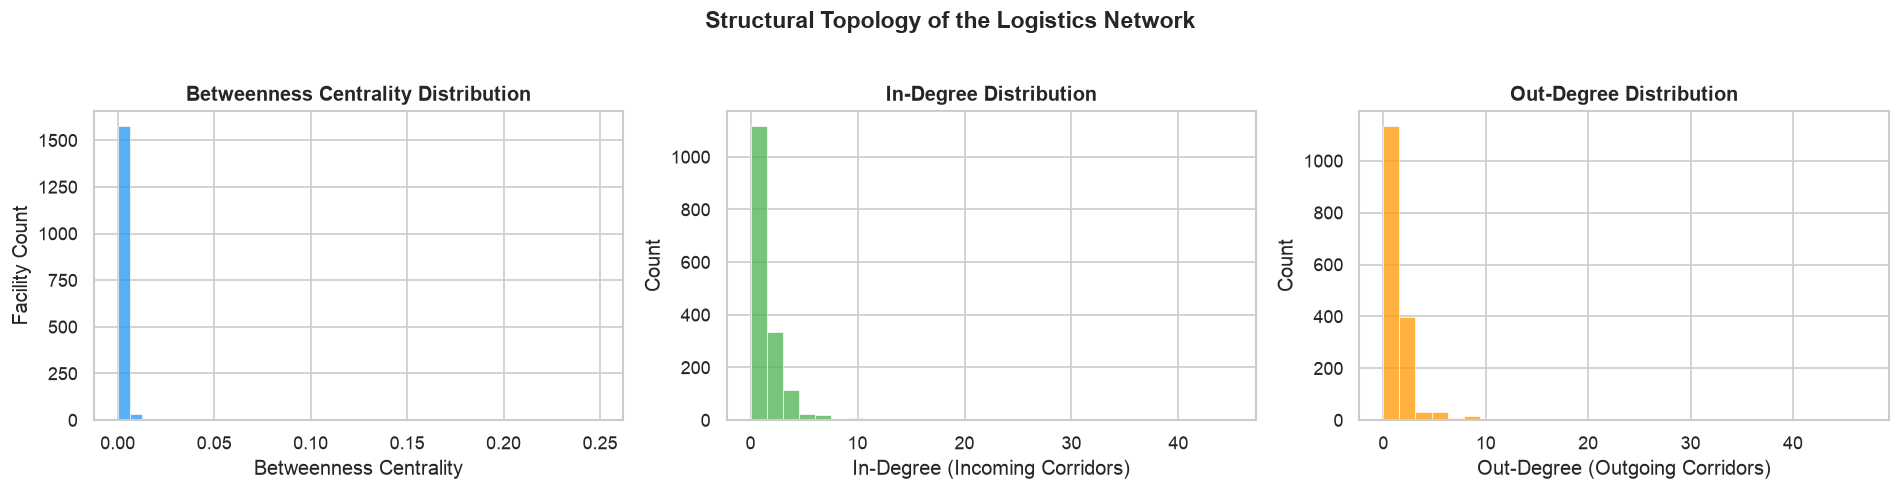

Saved: centrality_distributions.png


In [8]:
# ── Distribution plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(
    df_metrics["betweenness_centrality"], bins=40, ax=axes[0],
    color="#2196F3", edgecolor="white", linewidth=0.4
)
axes[0].set_title("Betweenness Centrality Distribution", fontweight="bold")
axes[0].set_xlabel("Betweenness Centrality")
axes[0].set_ylabel("Facility Count")

sns.histplot(
    df_metrics["in_degree"], bins=30, ax=axes[1],
    color="#4CAF50", edgecolor="white", linewidth=0.4
)
axes[1].set_title("In-Degree Distribution", fontweight="bold")
axes[1].set_xlabel("In-Degree (Incoming Corridors)")

sns.histplot(
    df_metrics["out_degree"], bins=30, ax=axes[2],
    color="#FF9800", edgecolor="white", linewidth=0.4
)
axes[2].set_title("Out-Degree Distribution", fontweight="bold")
axes[2].set_xlabel("Out-Degree (Outgoing Corridors)")

plt.suptitle(
    "Structural Topology of the Logistics Network",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("centrality_distributions.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: centrality_distributions.png")

---
## Section 4 — Bottleneck Discovery: The 20 % SLA Threshold

### 4.1 — Business Logic

We define a **Chronic Delay Corridor** as any Source → Destination pair where:

$$
\text{Median}\left(\frac{\text{Actual Time}}{\text{OSRM Time}}\right) > 1.20
$$

This means the network *consistently* takes **at least 20 % longer** than OSRM predicts.
The word *consistently* is key — the median filters out one-off bad days and exposes
**structural, repeatable delay patterns**.

### 4.2 — Why > 1.20 (not > 1.0)?

A ratio of exactly 1.0 would mean perfect OSRM accuracy.  We allow a 20 % buffer
to account for:
- Real-world traffic not captured by OSRM
- Loading/unloading dwell time at facilities
- Normal variability in transit

Anything *beyond* 20 % represents **avoidable delay** — the exact kind that should
be caught and corrected by the ML model.

### 4.3 — SLA Breach Index

We define an **SLA Breach Severity Score** for each corridor:

$$
\text{SeverityScore}_{u\to v} = (\text{weight}_{u\to v} - 1.0) \times \text{TripCount}_{u\to v}
$$

This multiplies excess delay by volume, so a corridor that is 30 % slow on 1,000 trips
ranks *far* higher than one that is 50 % slow on 10 trips.

In [9]:
def discover_bottleneck_corridors(G: nx.DiGraph) -> pd.DataFrame:
    """
    Identify and rank all Chronic Delay Corridors in the logistics network.

    A corridor is flagged as a Chronic Delay Corridor when its median
    delay ratio (actual / OSRM) exceeds the SLA threshold of 1.20.

    Columns in the returned DataFrame
    ----------------------------------
    source_id, destination_id : str
        Node identifiers.
    source_label, destination_label : str
        Human-readable facility names.
    median_delay_ratio : float
        The edge weight — median(actual / OSRM).
    excess_delay_pct : float
        (weight - 1.0) * 100  → how many percent above OSRM baseline.
    trip_count : int
        Volume of observed trips on this corridor.
    median_actual_min : float
        Median actual transit time in minutes.
    median_osrm_min : float
        Median OSRM-predicted transit time in minutes.
    median_distance_km : float
        Median corridor distance in km.
    breach_severity_score : float
        (weight - 1.0) * trip_count  — combines delay magnitude with volume.

    Parameters
    ----------
    G : nx.DiGraph
        Graph with edge attributes set by ``build_directed_graph()``.

    Returns
    -------
    pd.DataFrame
        Rows for flagged corridors only, sorted descending by
        breach_severity_score.
    """
    records = []

    for src, dst, data in G.edges(data=True):
        if not data.get("is_chronic_delay", False):
            continue

        w          = data["weight"]
        trip_count = data["trip_count"]

        records.append({
            "source_id"            : src,
            "destination_id"       : dst,
            "source_label"         : G.nodes[src].get("label", src),
            "destination_label"    : G.nodes[dst].get("label", dst),
            "median_delay_ratio"   : w,
            "excess_delay_pct"     : (w - 1.0) * 100,
            "trip_count"           : trip_count,
            "median_actual_min"    : data.get("median_actual_time", np.nan),
            "median_osrm_min"      : data.get("median_osrm_time",   np.nan),
            "median_distance_km"   : data.get("median_distance_km", np.nan),
            "breach_severity_score": (w - 1.0) * trip_count,
        })

    if not records:
        log.warning(
            "No chronic delay corridors found above threshold %.2f. "
            "Check that edge weights were correctly computed.", SLA_THRESHOLD
        )
        return pd.DataFrame()

    df_bottlenecks = (
        pd.DataFrame(records)
        .sort_values("breach_severity_score", ascending=False)
        .reset_index(drop=True)
    )

    n_flagged = len(df_bottlenecks)
    pct       = 100 * n_flagged / max(G.number_of_edges(), 1)
    log.info(
        "Flagged %d chronic-delay corridors out of %d total edges (%.1f%%)",
        n_flagged, G.number_of_edges(), pct,
    )
    log.info(
        "Worst corridor: %s → %s  (ratio=%.3f, score=%.1f)",
        df_bottlenecks.iloc[0]["source_label"],
        df_bottlenecks.iloc[0]["destination_label"],
        df_bottlenecks.iloc[0]["median_delay_ratio"],
        df_bottlenecks.iloc[0]["breach_severity_score"],
    )
    return df_bottlenecks

In [10]:
# ── Execute ────────────────────────────────────────────────────────────────
df_bottlenecks = discover_bottleneck_corridors(G)

print(f"Total chronic-delay corridors: {len(df_bottlenecks):,}")
print()
print("=== Top 20 Worst Chronic Delay Corridors (by Severity Score) ===")
display_cols = [
    "source_label", "destination_label",
    "median_delay_ratio", "excess_delay_pct",
    "trip_count", "breach_severity_score",
]
print(df_bottlenecks[display_cols].head(20).to_string(index=False))

INFO | Flagged 2452 chronic-delay corridors out of 2741 total edges (89.5%)
INFO | Worst corridor: Pune_Tathawde_H (Maharashtra) → Bhiwandi_Mankoli_HB (Maharashtra)  (ratio=2.810, score=193.6)


Total chronic-delay corridors: 2,452

=== Top 20 Worst Chronic Delay Corridors (by Severity Score) ===
                            source_label                    destination_label  median_delay_ratio  excess_delay_pct  trip_count  breach_severity_score
           Pune_Tathawde_H (Maharashtra)    Bhiwandi_Mankoli_HB (Maharashtra)              2.8095          180.9524         107               193.6190
        Mumbai_Chndivli_PC (Maharashtra)    Bhiwandi_Mankoli_HB (Maharashtra)              2.5000          150.0000          99               148.5000
            Surat_Central_D_12 (Gujarat)          Surat_Central_I_4 (Gujarat)              9.8333          883.3333          16               141.3333
             Benipatti_WardNo1_D (Bihar)          Muzaffrpur_Bbganj_I (Bihar)              9.9366          893.6625          15               134.0494
       Bhiwandi_Mankoli_HB (Maharashtra)             Mumbai Hub (Maharashtra)              2.2727          127.2727         105               

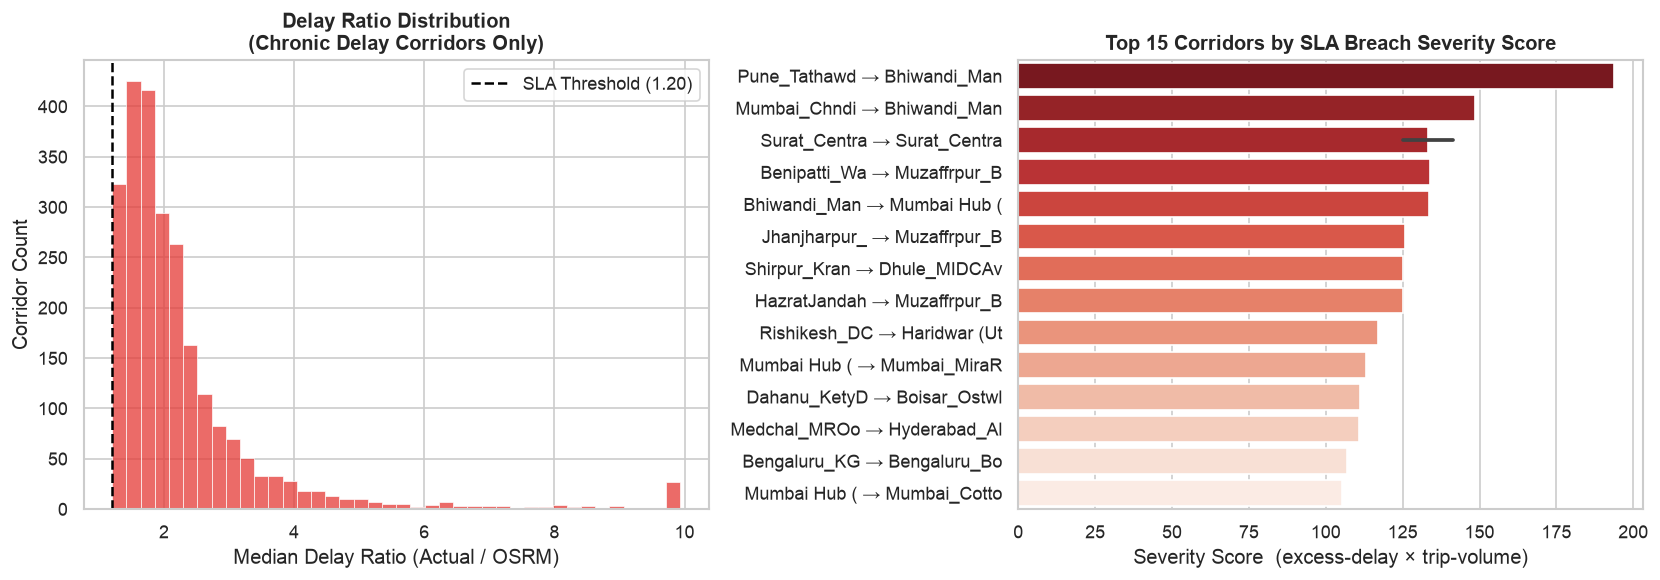

Saved: bottleneck_corridors.png


In [11]:
# ── Severity score distribution plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of delay ratios across flagged corridors
sns.histplot(
    df_bottlenecks["median_delay_ratio"], bins=40, ax=axes[0],
    color="#E53935", edgecolor="white", linewidth=0.4,
)
axes[0].axvline(
    SLA_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
    label=f"SLA Threshold ({SLA_THRESHOLD:.2f})"
)
axes[0].set_title("Delay Ratio Distribution\n(Chronic Delay Corridors Only)", fontweight="bold")
axes[0].set_xlabel("Median Delay Ratio (Actual / OSRM)")
axes[0].set_ylabel("Corridor Count")
axes[0].legend()

# Right: top 15 corridors by severity
top15 = df_bottlenecks.head(15).copy()
top15["corridor"] = (
    top15["source_label"].str[:12] + " → " + top15["destination_label"].str[:12]
)
sns.barplot(
    data=top15,
    y="corridor",
    x="breach_severity_score",
    ax=axes[1],
    palette="Reds_r",
)
axes[1].set_title("Top 15 Corridors by SLA Breach Severity Score", fontweight="bold")
axes[1].set_xlabel("Severity Score  (excess-delay × trip-volume)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("bottleneck_corridors.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: bottleneck_corridors.png")

---
## Section 5 — Network Visualisation & SLA Breach Ranking

### 5.1 — Visualisation Design Principles

The graph visualisation encodes **three independent data dimensions** simultaneously:

| Visual Property | Data Encoded | Interpretation |
|-----------------|-------------|----------------|
| **Node size** | Betweenness Centrality | Larger = more critical structural bridge |
| **Node color** | Degree Asymmetry | Blue = net dispatcher, Red = net receiver/bottleneck |
| **Edge color** | Delay ratio vs SLA | Red = chronic delay corridor, Gray = normal |
| **Edge width** | Trip count (volume) | Thicker = more observed trips |

### 5.2 — Layout Strategy

For logistics networks the `spring_layout` (Fruchterman-Reingold force-directed) algorithm
is appropriate: heavily connected hubs naturally cluster near the center, while
peripheral facilities are pushed outward.  The `weight` parameter is set to the
*inverse* of the delay ratio so that high-delay corridors appear spatially *longer*
(stretched apart) — which intuitively represents their inefficiency.

### 5.3 — Scalability Note

For very large graphs (> 200 nodes) the full node-label rendering becomes illegible.
The visualisation function automatically detects this and labels only the
top-N nodes by betweenness centrality.

In [14]:
def visualise_network(
    G: nx.DiGraph,
    df_metrics: pd.DataFrame,
    title: str = "Logistics Network — Phase 2 Audit",
    max_label_nodes: int = 30,
    figsize: Tuple[int, int] = (20, 16),
    seed: int = 42,
    output_path: str = "network_audit.png",
) -> None:
    """
    Render the full logistics network with bottleneck encoding.

    Visual encoding
    ---------------
    * Node size  ∝ betweenness_centrality (scaled to [300, 3000])
    * Node color → continuous diverging colormap on degree_asymmetry
                   (blue = net dispatcher, red = net receiver)
    * Edge color → red  for is_chronic_delay == True
                   gray for standard corridors
    * Edge width ∝ trip_count (scaled to [0.3, 3.5])
    * Labels shown only for top ``max_label_nodes`` nodes by BC

    Parameters
    ----------
    G : nx.DiGraph
    df_metrics : pd.DataFrame
        Output of ``compute_centrality_metrics()``.
    title : str
        Figure title.
    max_label_nodes : int
        Cap on how many node labels to render (readability).
    figsize : tuple
        Matplotlib figure size.
    seed : int
        RNG seed for reproducible spring layout.
    output_path : str
        File path to save the PNG.
    """
    log.info("Rendering network visualisation…")
    nodes = list(G.nodes())
    n     = len(nodes)

    # ── Layout ────────────────────────────────────────────────────────────
    # Use inverse weight so high-delay corridors appear stretched
    inv_weight_G = G.copy()
    for u, v, d in inv_weight_G.edges(data=True):
        inv_weight_G[u][v]["inv_weight"] = 1.0 / max(d.get("weight", 1.0), 0.01)

    pos = nx.spring_layout(
        inv_weight_G,
        weight="inv_weight",
        seed=seed,
        k=2.0 / max(n ** 0.5, 1),
    )

    # ── Node sizing: betweenness centrality ───────────────────────────────
    bc_vals = np.array([G.nodes[v].get("betweenness_centrality", 0) for v in nodes])
    if bc_vals.max() > 0:
        bc_norm = (bc_vals - bc_vals.min()) / (bc_vals.max() - bc_vals.min() + 1e-12)
    else:
        bc_norm = np.zeros(n)
    node_sizes = 300 + bc_norm * 2700   # range [300, 3000]

    # ── Node colouring: degree asymmetry ─────────────────────────────────
    asym_vals = np.array([G.nodes[v].get("degree_asymmetry", 0) for v in nodes])
    cmap_nodes = matplotlib.colormaps["RdYlBu_r"]
    asym_norm  = mcolors.Normalize(vmin=-1, vmax=1)
    node_colors= [cmap_nodes(asym_norm(a)) for a in asym_vals]

    # ── Edge colouring and widths ─────────────────────────────────────────
    edges          = list(G.edges(data=True))
    edge_colors    = []
    edge_widths    = []
    edge_alphas    = []

    all_trips = [d.get("trip_count", 1) for _, _, d in edges]
    max_trips  = max(all_trips) if all_trips else 1

    for _, _, d in edges:
        is_chronic = d.get("is_chronic_delay", False)
        edge_colors.append("#D32F2F" if is_chronic else "#BDBDBD")
        tc = d.get("trip_count", 1)
        edge_widths.append(0.3 + 3.2 * (tc / max_trips))
        edge_alphas.append(0.85 if is_chronic else 0.35)

    # ── Render ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor="#F8F9FA")
    ax.set_facecolor("#F8F9FA")
    ax.axis("off")

    # Draw edges (normal first, then chronic on top)
    normal_edges  = [(u,v) for (u,v,d) in edges if not d.get("is_chronic_delay")]
    chronic_edges = [(u,v) for (u,v,d) in edges if  d.get("is_chronic_delay")]
    normal_widths = [w for w, (_, _, d) in zip(edge_widths, edges) if not d.get("is_chronic_delay")]
    chronic_widths= [w for w, (_, _, d) in zip(edge_widths, edges) if  d.get("is_chronic_delay")]

    nx.draw_networkx_edges(
        G, pos, edgelist=normal_edges, width=normal_widths,
        edge_color="#BDBDBD", alpha=0.30, arrows=True,
        arrowsize=6, arrowstyle="-|>",
        connectionstyle="arc3,rad=0.08", ax=ax,
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=chronic_edges, width=chronic_widths,
        edge_color="#D32F2F", alpha=0.75, arrows=True,
        arrowsize=10, arrowstyle="-|>",
        connectionstyle="arc3,rad=0.08", ax=ax,
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.92,
        linewidths=0.8,
        edgecolors="white",
        ax=ax,
    )

    # Labels for top-N nodes only
    top_nodes = set(
        df_metrics.nlargest(min(max_label_nodes, n), "betweenness_centrality")["facility_id"]
    )
    label_dict = {
        v: G.nodes[v].get("label", v)[:15]
        for v in nodes if v in top_nodes
    }
    nx.draw_networkx_labels(
        G, pos,
        labels=label_dict,
        font_size=7,
        font_color="#212121",
        font_weight="bold",
        ax=ax,
    )

    # ── Legend ────────────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor="#D32F2F", label=f"Chronic Delay Corridor (ratio > {SLA_THRESHOLD:.2f})"),
        mpatches.Patch(facecolor="#BDBDBD", label="Normal Corridor"),
        mpatches.Patch(facecolor="#2196F3", label="Net Dispatcher (out > in)"),
        mpatches.Patch(facecolor="#F44336", label="Net Receiver (in > out) — Bottleneck Risk"),
        mpatches.Patch(facecolor="white",   label="Node size ∝ Betweenness Centrality"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=9,
        framealpha=0.9,
        fancybox=True,
    )

    # Colorbar for node colour
    sm = cm.ScalarMappable(cmap=cmap_nodes, norm=asym_norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.35, pad=0.01, location="right")
    cbar.set_label("Degree Asymmetry\n(+1 = pure receiver, −1 = pure dispatcher)", fontsize=8)

    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=150)
    plt.show()
    log.info("Saved: %s", output_path)

INFO | Rendering network visualisation…


/var/folders/d8/ndxwgv7x2ng126yjvd19mdj80000gn/T/ipykernel_37652/3400490639.py:161: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/d8/ndxwgv7x2ng126yjvd19mdj80000gn/T/ipykernel_37652/3400490639.py:162: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(output_path, bbox_inches="tight", dpi=150)
/Users/bhaveshnegi/Desktop/C&A Project/ETA Estimation Project/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


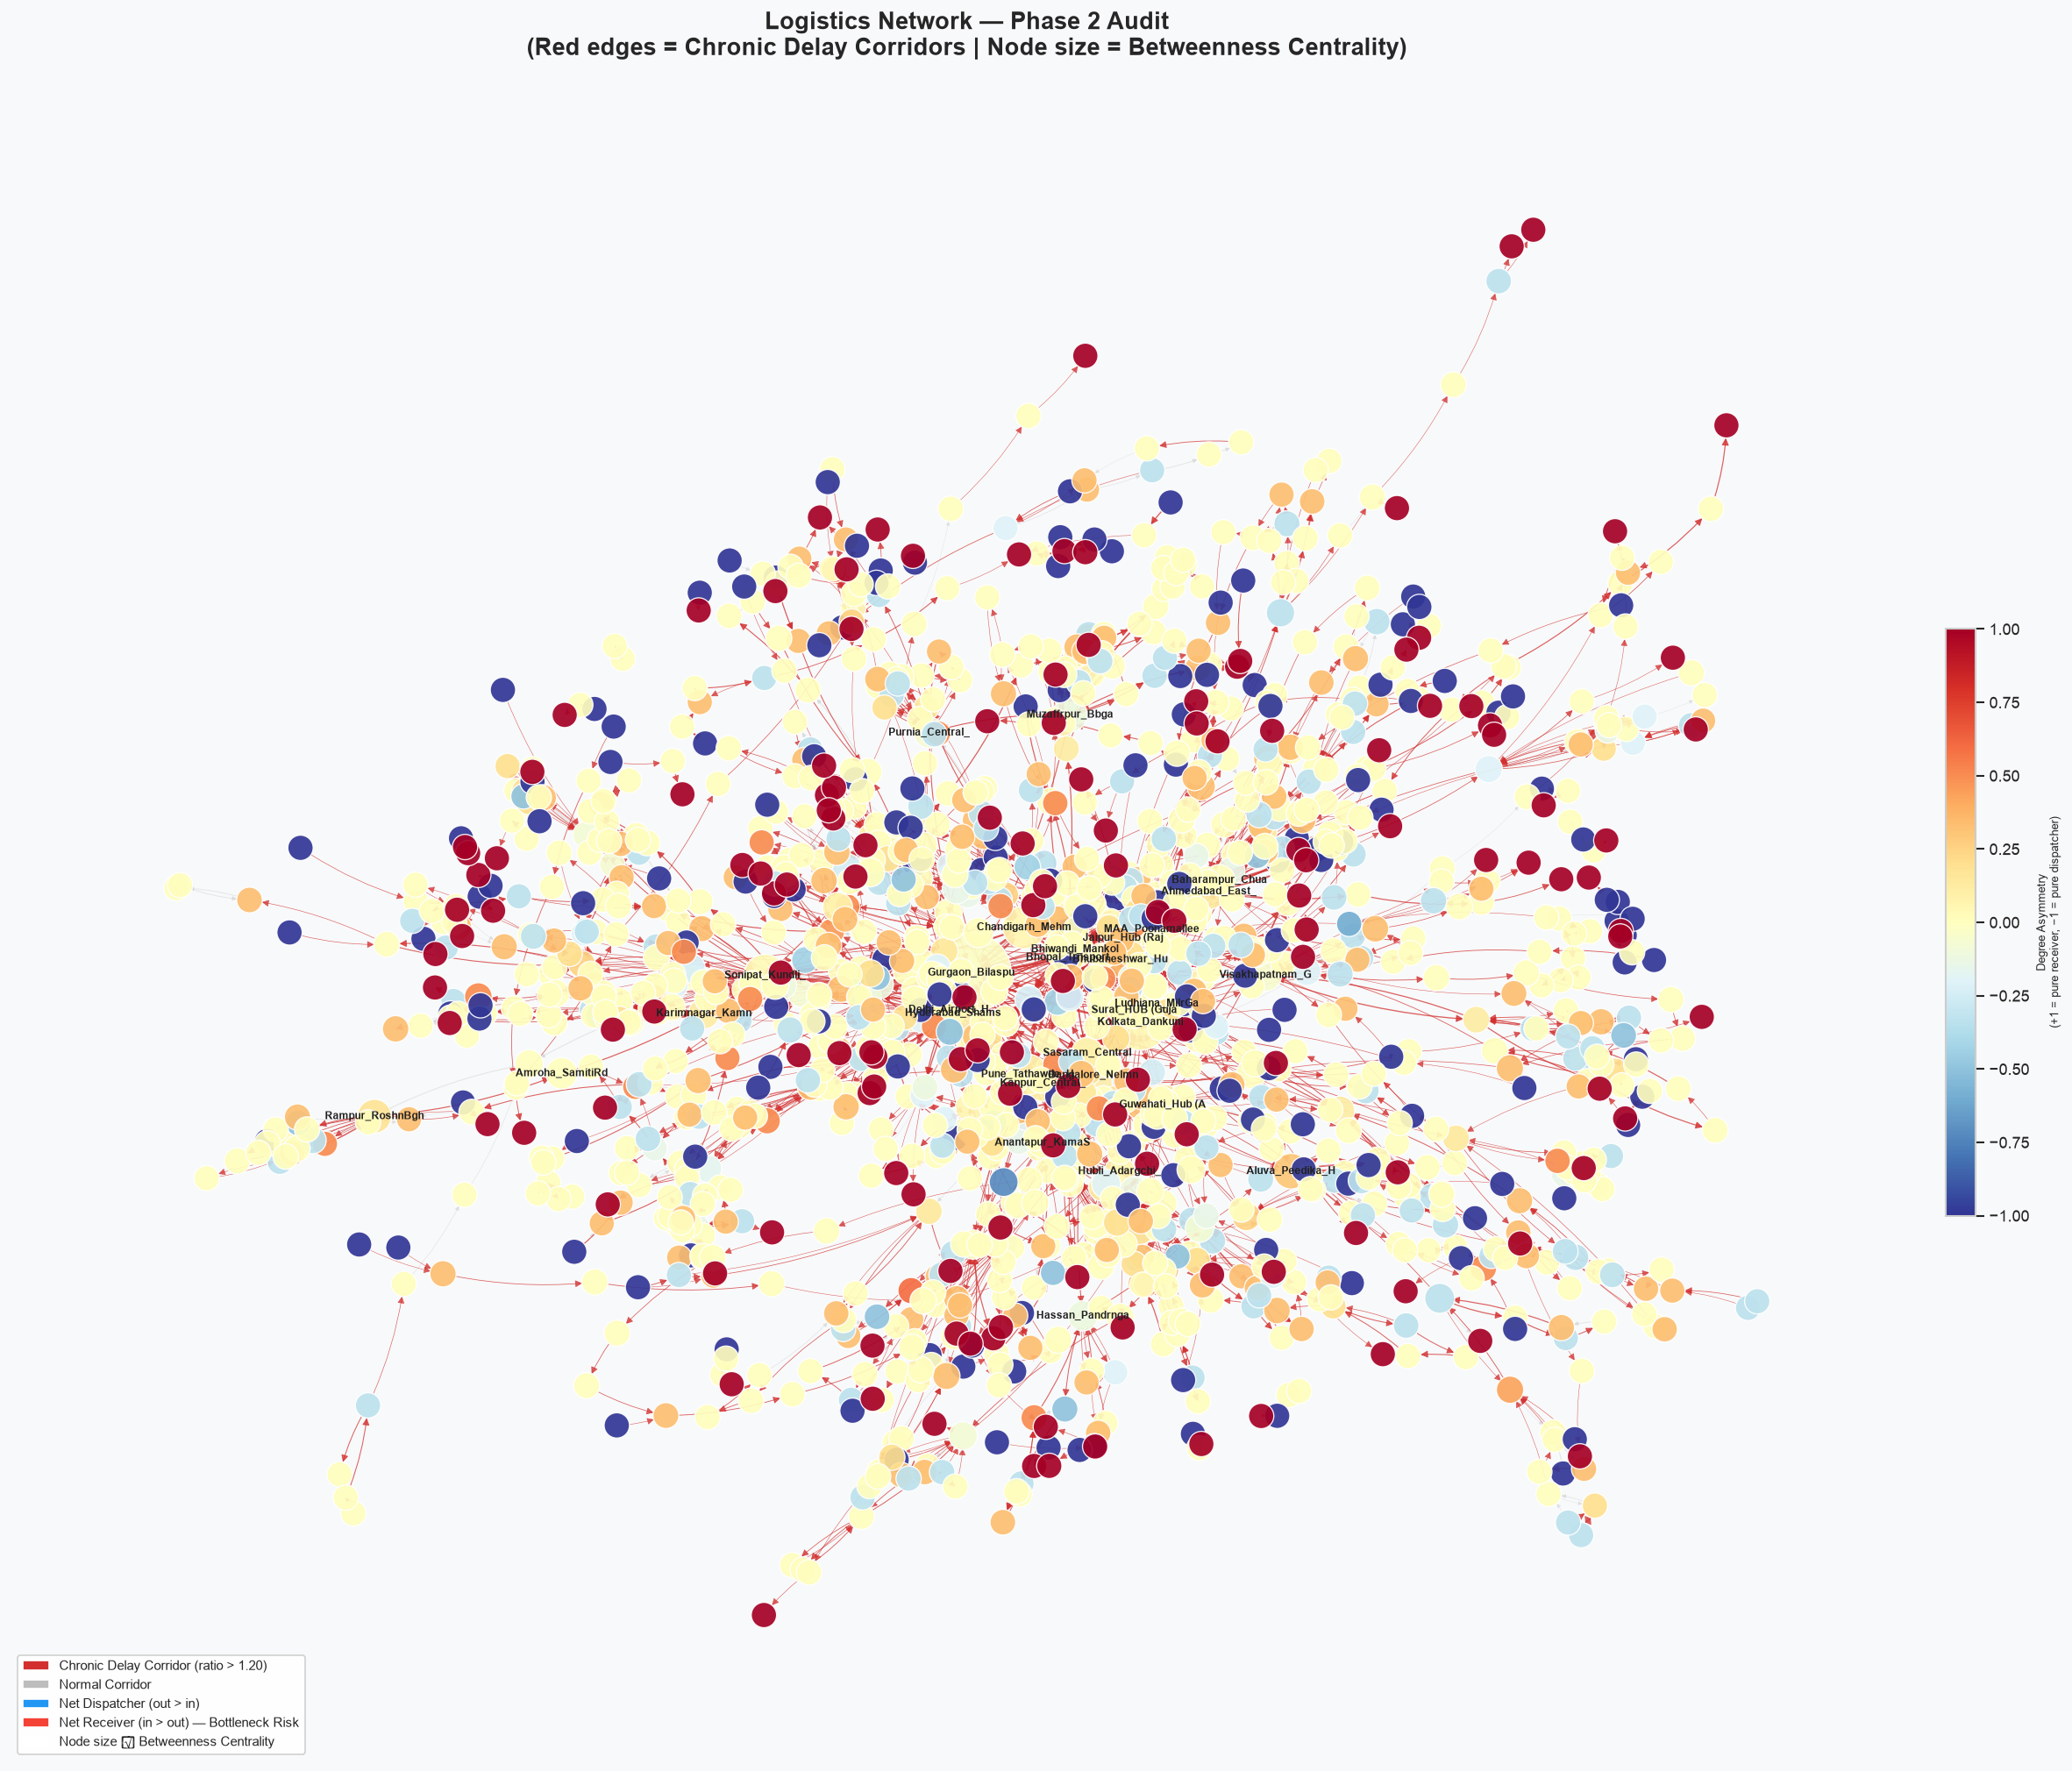

INFO | Saved: network_audit_full.png


In [15]:
# ── Execute ────────────────────────────────────────────────────────────────
visualise_network(
    G,
    df_metrics,
    title="Logistics Network — Phase 2 Audit\n(Red edges = Chronic Delay Corridors | Node size = Betweenness Centrality)",
    max_label_nodes=30,
    figsize=(22, 17),
    output_path="network_audit_full.png",
)

---
## Section 6 — SLA Breach Ranking: Top 10 Worst Offender Facilities

### 6.1 — Aggregation Logic

We now **elevate from corridors to facilities**.  A corridor has two endpoints — each
endpoint facility *contributes* to the delay.  We aggregate the SLA breach evidence
at the facility level by:

1. **Counting** how many chronic-delay corridors touch each facility (as either source or destination).
2. **Summing** the Breach Severity Score across all connected chronic corridors.
3. **Computing** the mean delay ratio across all connected chronic corridors.
4. **Joining** with Betweenness Centrality — a high-BC facility that *also* has high
   SLA breach counts is the most critical node in the network.

### 6.2 — Composite Risk Score

$$
\text{CompositeRisk}_v = 
  \underbrace{\text{NormBC}_v}_{\text{structural importance}} 
  \times 
  \underbrace{\text{NormSeverity}_v}_{\text{delay evidence}}
$$

Both components are min-max normalised to $[0, 1]$ before multiplication,
giving a score that is high only when a facility is *both* a structural
bridge *and* a chronic delay contributor.

In [16]:
def rank_sla_breach_facilities(
    G: nx.DiGraph,
    df_bottlenecks: pd.DataFrame,
    df_metrics: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    """
    Aggregate chronic-delay corridor evidence to the facility level and
    produce a ranked DataFrame of the worst SLA offender hubs.

    Parameters
    ----------
    G : nx.DiGraph
    df_bottlenecks : pd.DataFrame
        Output of ``discover_bottleneck_corridors()``.
    df_metrics : pd.DataFrame
        Output of ``compute_centrality_metrics()``.
    top_n : int
        Number of top offenders to return.

    Returns
    -------
    pd.DataFrame
        Ranked facilities with composite risk score.
    """
    if df_bottlenecks.empty:
        log.warning("No bottlenecks to rank — returning empty DataFrame.")
        return pd.DataFrame()

    # ── Melt: each corridor touches two facilities ─────────────────────────
    src_contribution = df_bottlenecks.rename(columns={
        "source_id":     "facility_id",
        "source_label":  "facility_label",
    })[["facility_id", "facility_label", "breach_severity_score", "median_delay_ratio"]]

    dst_contribution = df_bottlenecks.rename(columns={
        "destination_id":    "facility_id",
        "destination_label": "facility_label",
    })[["facility_id", "facility_label", "breach_severity_score", "median_delay_ratio"]]

    combined = pd.concat([src_contribution, dst_contribution], ignore_index=True)

    # ── Aggregate per facility ─────────────────────────────────────────────
    agg = (
        combined.groupby(["facility_id", "facility_label"])
        .agg(
            total_severity_score   = ("breach_severity_score", "sum"),
            chronic_corridor_count = ("breach_severity_score", "count"),
            mean_delay_ratio       = ("median_delay_ratio",    "mean"),
            max_delay_ratio        = ("median_delay_ratio",    "max"),
        )
        .reset_index()
    )

    # ── Join betweenness centrality ────────────────────────────────────────
    agg = agg.merge(
        df_metrics[["facility_id", "betweenness_centrality",
                    "in_degree", "out_degree", "degree_asymmetry"]],
        on="facility_id",
        how="left",
    )

    # ── Composite risk score ───────────────────────────────────────────────
    def minmax_norm(series: pd.Series) -> pd.Series:
        r = series.max() - series.min()
        return (series - series.min()) / r if r > 0 else series * 0

    agg["norm_severity"]   = minmax_norm(agg["total_severity_score"])
    agg["norm_bc"]         = minmax_norm(agg["betweenness_centrality"])
    agg["composite_risk"]  = agg["norm_severity"] * agg["norm_bc"]

    ranked = (
        agg.sort_values("composite_risk", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    ranked.index += 1   # 1-based ranking

    log.info("Top-%d worst-offender facilities computed.", top_n)
    return ranked

In [17]:
# ── Execute ────────────────────────────────────────────────────────────────
df_top_offenders = rank_sla_breach_facilities(
    G, df_bottlenecks, df_metrics, top_n=10
)

print("\n" + "="*70)
print("   TOP 10 WORST OFFENDER FACILITIES — SLA BREACH RANKING")
print("="*70)
display_cols = [
    "facility_label",
    "chronic_corridor_count",
    "mean_delay_ratio",
    "max_delay_ratio",
    "total_severity_score",
    "betweenness_centrality",
    "composite_risk",
]
print(df_top_offenders[display_cols].to_string())
print("="*70)

INFO | Top-10 worst-offender facilities computed.



   TOP 10 WORST OFFENDER FACILITIES — SLA BREACH RANKING
                       facility_label  chronic_corridor_count  mean_delay_ratio  max_delay_ratio  total_severity_score  betweenness_centrality  composite_risk
1       Gurgaon_Bilaspur_HB (Haryana)                      85            1.8287           5.4494             1356.0610                  0.2495          0.7096
2    Bangalore_Nelmngla_H (Karnataka)                      68            1.6445           4.0000              755.8909                  0.1374          0.2178
3    Kolkata_Dankuni_HB (West Bengal)                      46            3.1879           9.9366              911.0018                  0.1081          0.2065
4   Bhiwandi_Mankoli_HB (Maharashtra)                      58            2.4844           5.5714             1910.8785                  0.0318          0.1274
5    Hyderabad_Shamshbd_H (Telangana)                      56            2.0072           9.9366              622.8349                  0.0847     

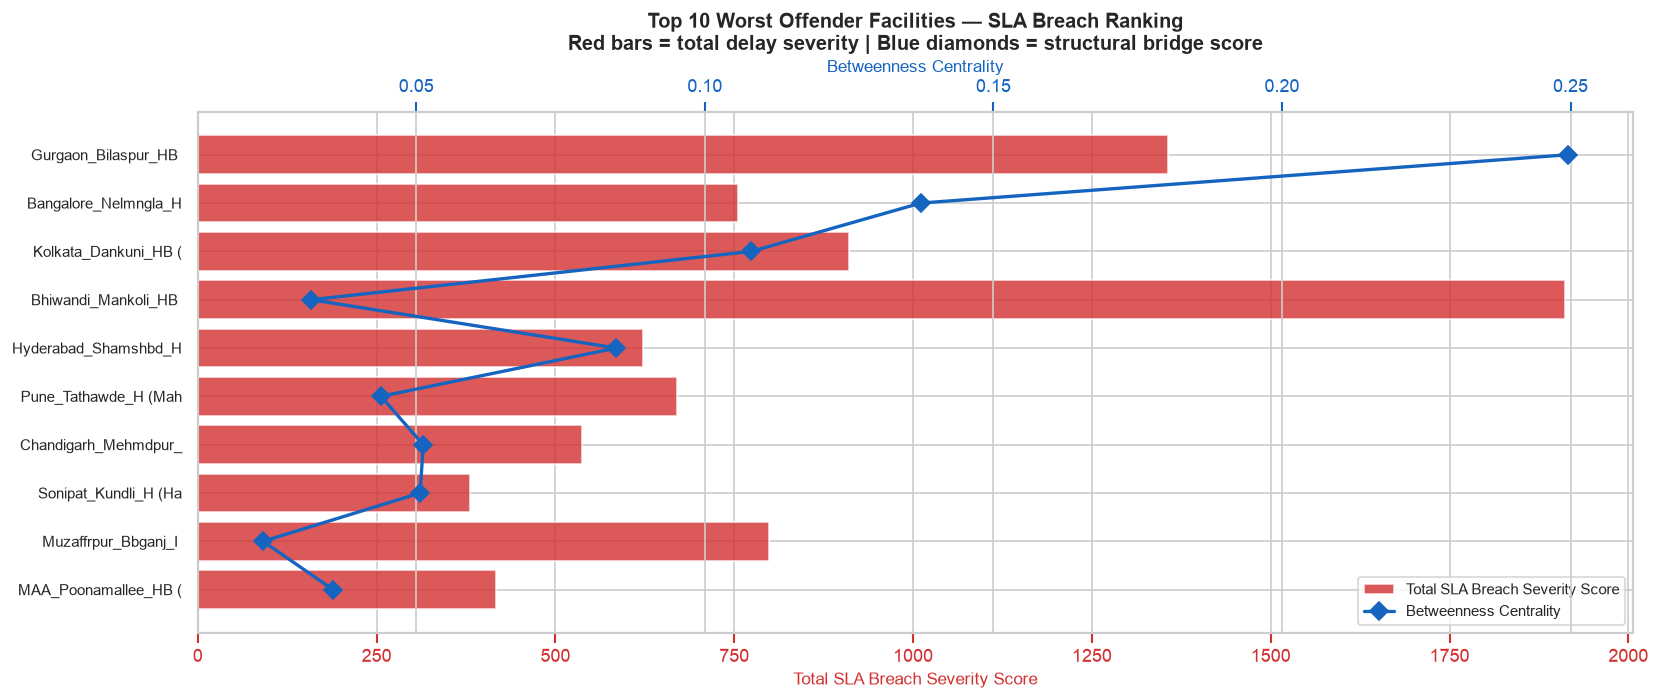

Saved: top10_offenders.png


In [18]:
# ── Dual-axis bar + line chart for the Top-10 offenders ───────────────────
if not df_top_offenders.empty:
    fig, ax1 = plt.subplots(figsize=(14, 6))

    y_pos  = np.arange(len(df_top_offenders))
    labels = df_top_offenders["facility_label"].str[:20].tolist()

    # Bar: total severity score
    bars = ax1.barh(
        y_pos,
        df_top_offenders["total_severity_score"],
        color="#D32F2F",
        alpha=0.80,
        label="Total SLA Breach Severity Score",
    )
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(labels, fontsize=9)
    ax1.invert_yaxis()
    ax1.set_xlabel("Total SLA Breach Severity Score", color="#D32F2F", fontsize=10)
    ax1.tick_params(axis="x", colors="#D32F2F")

    # Secondary axis: betweenness centrality
    ax2 = ax1.twiny()
    ax2.plot(
        df_top_offenders["betweenness_centrality"].values,
        y_pos,
        marker="D",
        color="#1565C0",
        linewidth=2,
        markersize=8,
        label="Betweenness Centrality",
    )
    ax2.set_xlabel("Betweenness Centrality", color="#1565C0", fontsize=10)
    ax2.tick_params(axis="x", colors="#1565C0")

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=9)

    plt.title(
        "Top 10 Worst Offender Facilities — SLA Breach Ranking\n"
        "Red bars = total delay severity | Blue diamonds = structural bridge score",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig("top10_offenders.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: top10_offenders.png")

---
## Section 7 — Artifact Export for Phase 3

All computed artefacts are persisted to disk so that Phase 3 (GraphSAGE feature
engineering) can load them directly without re-running this notebook.

In [19]:
def export_artifacts(
    G: nx.DiGraph,
    df_clean: pd.DataFrame,
    df_metrics: pd.DataFrame,
    df_bottlenecks: pd.DataFrame,
    df_top_offenders: pd.DataFrame,
    output_dir: str = "phase2_artifacts",
) -> None:
    """
    Persist all Phase 2 outputs to disk.

    Files Written
    -------------
    node_metrics.csv           — Per-facility centrality metrics
    chronic_delay_corridors.csv — Flagged SLA-breach edges
    top10_offenders.csv        — Ranked worst-offender facilities
    network_graph.graphml      — Full DiGraph with all node/edge attributes
    clean_data.parquet         — Cleaned segment DataFrame (Parquet for speed)

    Parameters
    ----------
    G, df_clean, df_metrics, df_bottlenecks, df_top_offenders : outputs
        of the preceding pipeline functions.
    output_dir : str
        Directory to write into (created if it does not exist).
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    df_metrics.to_csv(out / "node_metrics.csv", index=False)
    log.info("Saved: node_metrics.csv")

    if not df_bottlenecks.empty:
        df_bottlenecks.to_csv(out / "chronic_delay_corridors.csv", index=False)
        log.info("Saved: chronic_delay_corridors.csv")

    if not df_top_offenders.empty:
        df_top_offenders.to_csv(out / "top10_offenders.csv", index=False)
        log.info("Saved: top10_offenders.csv")

    nx.write_graphml(G, str(out / "network_graph.graphml"))
    log.info("Saved: network_graph.graphml")

    try:
        df_clean.to_parquet(out / "clean_data.parquet", index=False)
        log.info("Saved: clean_data.parquet")
    except Exception as e:
        log.warning("Parquet export failed (%s) — saving as CSV instead.", e)
        df_clean.to_csv(out / "clean_data.csv", index=False)

    log.info("All Phase 2 artifacts written to: %s/", output_dir)

# ── Execute ────────────────────────────────────────────────────────────────
export_artifacts(G, df_clean, df_metrics, df_bottlenecks, df_top_offenders)

INFO | Saved: node_metrics.csv
INFO | Saved: chronic_delay_corridors.csv
INFO | Saved: top10_offenders.csv
INFO | Saved: network_graph.graphml
INFO | Saved: clean_data.parquet
INFO | All Phase 2 artifacts written to: phase2_artifacts/


---
## Section 8 — Executive Summary: Key Findings

This cell programmatically generates a strategy-memo-ready summary from the computed data.
Run it after all preceding sections complete.

In [20]:
def print_executive_summary(
    G: nx.DiGraph,
    df_metrics: pd.DataFrame,
    df_bottlenecks: pd.DataFrame,
    df_top_offenders: pd.DataFrame,
) -> None:
    """
    Print a structured, strategy-memo-ready executive summary of Phase 2 findings.
    """
    total_edges    = G.number_of_edges()
    total_nodes    = G.number_of_nodes()
    n_chronic      = len(df_bottlenecks)
    pct_chronic    = 100 * n_chronic / max(total_edges, 1)

    top_bc_node    = df_metrics.iloc[0]
    worst_corridor = df_bottlenecks.iloc[0] if not df_bottlenecks.empty else None
    top_offender   = df_top_offenders.iloc[0] if not df_top_offenders.empty else None

    print("\n" + "╔" + "═"*68 + "╗")
    print("║" + "   PHASE 2 NETWORK AUDIT — EXECUTIVE SUMMARY".center(68) + "║")
    print("╠" + "═"*68 + "╣")
    print(f"║  Network Scale                                                    ║")
    print(f"║    Total Facilities (Nodes)  : {total_nodes:<6,}                             ║")
    print(f"║    Total Corridors (Edges)   : {total_edges:<6,}                             ║")
    print(f"║                                                                    ║")
    print(f"║  SLA Breach Summary                                                ║")
    print(f"║    Chronic Delay Corridors   : {n_chronic:<6,} ({pct_chronic:.1f}% of all corridors)  ║")
    print(f"║    SLA Threshold Applied     : > {SLA_THRESHOLD:.0%} of OSRM baseline          ║")
    print(f"║                                                                    ║")

    if top_bc_node is not None:
        print(f"║  Critical Structural Bridge (Highest Betweenness Centrality)       ║")
        print(f"║    Facility : {str(top_bc_node['label'])[:48]:<48}  ║")
        print(f"║    BC Score : {top_bc_node['betweenness_centrality']:.6f}                               ║")
        print(f"║    In/Out   : {int(top_bc_node['in_degree'])} in / {int(top_bc_node['out_degree'])} out{chr(32)*38}║")
        print(f"║                                                                    ║")

    if worst_corridor is not None:
        print(f"║  Single Worst Delay Corridor                                       ║")
        print(f"║    Route    : {str(worst_corridor['source_label'])[:18]} → {str(worst_corridor['destination_label'])[:18]:<20}║")
        print(f"║    Ratio    : {worst_corridor['median_delay_ratio']:.3f}x OSRM ({worst_corridor['excess_delay_pct']:.1f}% excess delay){chr(32)*13}║")
        print(f"║    Trips    : {int(worst_corridor['trip_count']):<6,}                                         ║")
        print(f"║                                                                    ║")

    if top_offender is not None:
        print(f"║  #1 Worst Offender Facility                                        ║")
        print(f"║    Facility : {str(top_offender['facility_label'])[:48]:<48}  ║")
        print(f"║    Chronic Corridors : {int(top_offender['chronic_corridor_count']):<4}                                  ║")
        print(f"║    Composite Risk    : {top_offender['composite_risk']:.6f}                              ║")

    print("╚" + "═"*68 + "╝")
    print()
    print("Next Step → Phase 3: GraphSAGE Feature Engineering")
    print("  Load: phase2_artifacts/network_graph.graphml")
    print("  Use node attributes: betweenness_centrality, degree_asymmetry,")
    print("                       weighted_in_strength, weighted_out_strength")
    print("  Use edge attributes: weight (delay ratio), is_chronic_delay,")
    print("                       median_distance_km, trip_count")

# ── Execute ────────────────────────────────────────────────────────────────
print_executive_summary(G, df_metrics, df_bottlenecks, df_top_offenders)


╔════════════════════════════════════════════════════════════════════╗
║               PHASE 2 NETWORK AUDIT — EXECUTIVE SUMMARY            ║
╠════════════════════════════════════════════════════════════════════╣
║  Network Scale                                                    ║
║    Total Facilities (Nodes)  : 1,641                              ║
║    Total Corridors (Edges)   : 2,741                              ║
║                                                                    ║
║  SLA Breach Summary                                                ║
║    Chronic Delay Corridors   : 2,452  (89.5% of all corridors)  ║
║    SLA Threshold Applied     : > 120% of OSRM baseline          ║
║                                                                    ║
║  Critical Structural Bridge (Highest Betweenness Centrality)       ║
║    Facility : Gurgaon_Bilaspur_HB (Haryana)                     ║
║    BC Score : 0.249512                               ║
║    In/Out   : 45 in / 47 out 